# Fitting the GRB Spectrum with the Binned Relative-Coordinates Response

## Introduction

This notebook is a companion to
[example_grb_fit_normalizing_flows.ipynb](example_grb_fit_normalizing_flows.ipynb), which
introduces the classes used for unbinned spectral fitting (`UnbinnedThreeMLPointSourceResponseIRFAdaptive`,
`CachedUnbinnedThreeMLModelFolding`, etc.) -- see that notebook for details on those. Here we
only cover what's different: the response itself.

`IRFRelativeHistUnpolarized` evaluates the response by interpolating a 6D histogram
(`NuLambda, Ei, Epsilon, Phi, Theta, Zeta`) binned in *relative* coordinates (relative to the
photon's incoming direction and energy), instead of evaluating a neural network. It doesn't need
a GPU and is much cheaper to query, at the cost of some accuracy (see
[this presentation](https://github.com/user-attachments/files/31315263/20260428-BinnedRelResponse-cosipy-Israel.pdf)
for how it's built and a first comparison against the neural-network response).

This notebook demonstrates two ways of building that histogram, selected below via `irf_mode`:

- `"hist_simple"`: the histogram built directly from a MEGAlib simulation binned in relative
  coordinates (see `cosipy/response/scripts/IRFRelativeHist/relative_hist_irf_from_rsp.py`).
  I applied some smoothing to deal with limited statistics, which biased the IRF a bit.
- `"hist_nn"`: the same kind of histogram, but built by evaluating the neural-network response
  on a grid instead of from a MEGAlib simulation + smoothing (see
  `cosipy/response/scripts/IRFRelativeHist/relative_hist_irf_from_nf_response.py`).

For reference, `"nn"` is also available, and simply reuses the neural-network response directly
(no histogram), exactly as in the other notebook.

Both the "hist" IRF and the NN IRF use the same batch of MEGAlib simulated events.

### Choose the response mode

In [1]:
irf_mode = "hist_nn"  # one of "hist_simple", "hist_nn", "nn"


### Basic Setup

In [2]:
from pathlib import Path
from cosipy.util import fetch_wasabi_file
from cosipy.spacecraftfile import SpacecraftHistory
from astropy.time import Time

import astropy.units as u
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from threeML import Band, PointSource, Model, JointLikelihood, DataList

from cosipy.threeml.unbinned_model_folding import CachedUnbinnedThreeMLModelFolding
from cosipy.statistics import UnbinnedLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.interfaces.expectation_interface import SumExpectationDensity

from cosipy.event_selection import DistanceSelector, ChainEventSelectors
from cosipy.event_selection.time_selection import TimeSelector
from cosipy.data_io.EmCDSUnbinnedData import TimeTagEmCDSDistanceEventDataInSCFrameFromDC3Fits

from cosipy.response.ml.NFResponse import NFResponse
from cosipy.response.ml.nf_instrument_response_function import UnpolarizedNFFarFieldInstrumentResponseFunction
from cosipy.response.relative_irf_hist import IRFRelativeHistUnpolarized

from cosipy.threeml.ml.optimized_unbinned_folding import UnbinnedThreeMLPointSourceResponseIRFAdaptive


12:59:21 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=4565861;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=4565862;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=4565868;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=4565869;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=4565876;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=4565877;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

12:59:22 INFO      Starting 3ML!                                                                     ]8;id=4565884;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=4565885;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=4565891;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=4565892;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=4565934;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=4565935;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=4565942;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=4565943;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=4565949;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=4565950;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=4565955;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=4565956;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=4565961;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=4565962;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

The GRB event data and spacecraft orientation are needed regardless of `irf_mode`; the
response file is not, so it's only fetched below for the mode actually selected above.

In [3]:
data_path = Path("./") # Current path by default

grb_data_path = data_path / "GRB_bn090424592_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
fetch_wasabi_file('COSI-SMEX/DC3/Data/Sources/GRB_bn090424592_3months_unbinned_data_filtered_with_SAAcut.fits.gz',
                  checksum = '08c1f1202d78df40a4aed3b785d273e0', output=str(grb_data_path))

sc_orientation_path = data_path / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits',
                  checksum = 'ca94ff1d7a73c1f41479aaf598807673', output=str(sc_orientation_path))


A file named GRB_bn090424592_3months_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (08c1f1202d78df40a4aed3b785d273e0). Skipping.


A file named DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits already exists with the specified checksum (ca94ff1d7a73c1f41479aaf598807673). Skipping.


In [4]:
if irf_mode == "nn":

    rsp_path = data_path / "unpolarized_nfresponse_v1-01.pt"
    fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/unpolarized_nfresponse_v1-01.pt',
                      checksum = 'bf2d0c16eac5954fb56489480c2602ca', output=str(rsp_path))

elif irf_mode == "hist_simple":

    hist_zip_path = data_path / "ResponseContinuum.area.relative.nonsparse.h5.zip"
    hist_path = data_path / "ResponseContinuum.area.relative.nonsparse.h5"
    fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.area.relative.nonsparse.h5.zip',
                      output=str(hist_zip_path), unzip=True,
                      checksum = '2a5ab4f227608349f934d219ffebc2f4')

elif irf_mode == "hist_nn":

    hist_nn_zip_path = data_path / "relative_hist_irf_from_nf_response.h5.zip"
    hist_nn_path = data_path / "relative_hist_irf_from_nf_response.h5"
    fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/relative_hist_irf_from_nf_response.h5.zip',
                      output=str(hist_nn_zip_path), unzip=True,
                      checksum = 'd9093daeaf56a386095a42ae40c6635e')

else:

    raise RuntimeError(f"irf_mode {irf_mode} is not supported.")


A file named relative_hist_irf_from_nf_response.h5 already exists with the specified checksum (d9093daeaf56a386095a42ae40c6635e). Skipping.


Define the observation duration here. This GRB lasts approximately 10 seconds.

In [5]:
tstart = Time("2028-03-24 10:36:42.000")
tstop = Time("2028-03-24 10:36:51.921")
sc_orientation = SpacecraftHistory.open(sc_orientation_path)
sc_orientation = sc_orientation.select_interval(tstart, tstop)


`"hist_simple"` also needs a distance cut (first-two-hits distance > 1 cm): the MEGAlib
simulation it was built from used that same cut to avoid strip-discretization artifacts near the
detector edges, so the event data needs to match. `"hist_nn"` and `"nn"` don't need it, since
they aren't built using that cut.

I set >1cm because those events:
* Make the response very complicated to model, due to position discretization.
* Are very low quality anyway. Their corresponding ARM is very bad, so they don’t give you much resolution nor sensitivity.

Eventually we'll add the distance as a parameter of the IRF, but for now filtering out these is a net positive.

In [6]:
time_selector = TimeSelector(tstart = sc_orientation.tstart, tstop = sc_orientation.tstop)

if irf_mode == "hist_simple":
    selector = ChainEventSelectors(DistanceSelector(min_distance=1 * u.cm), time_selector)
else:
    selector = time_selector

data = TimeTagEmCDSDistanceEventDataInSCFrameFromDC3Fits([grb_data_path], selection=selector)


In [7]:
print(f"This analysis uses {data.nevents} Events")


This analysis uses 105221 Events


### Building the response

- `"nn"` builds `NFResponse` as in the other notebook (see there for a description of its
  `devices`/`compile_mode` arguments) and wraps it in `UnpolarizedNFFarFieldInstrumentResponseFunction`.
- `"hist_simple"` and `"hist_nn"` just load the pre-built histogram with
  `IRFRelativeHistUnpolarized.from_h5()` -- no compute pool or GPU involved.

In [8]:
if irf_mode == "nn":

    rsp = NFResponse(
        path_to_model=rsp_path,
        area_batch_size=300_000,
        density_batch_size=100_000,
        devices=["cpu"],
        area_compile_mode=None,
        density_compile_mode=None,
        show_progress=True)

    irf = UnpolarizedNFFarFieldInstrumentResponseFunction(rsp)

elif irf_mode == "hist_simple":

    irf = IRFRelativeHistUnpolarized.from_h5(hist_path)

elif irf_mode == "hist_nn":

    irf = IRFRelativeHistUnpolarized.from_h5(hist_nn_path)



WARNING RuntimeWarning: invalid value encountered in divide



In [9]:
psr = UnbinnedThreeMLPointSourceResponseIRFAdaptive(
    data=data,
    irf=irf,
    sc_history=sc_orientation,
    show_progress=True,
    force_energy_node_caching=True,
    reduce_memory=True)

psr.cache_batch_size = 100_000
psr.integration_batch_size = 100_000


In [10]:
l = 21.293418951586656
b = -42.384846594045484

alpha = -1.021866
beta = -2.762827
xp = 159.9995 * u.keV
piv = 100. * u.keV
K = 5.2385389556 / u.cm / u.cm / u.s / u.keV

spectrum = Band(beta=beta, K=K.value, piv=piv.value)

spectrum.alpha.delta = 0.01
spectrum.beta.delta = 0.01

spectrum.alpha.value = alpha
spectrum.xp.value = xp.value

spectrum.xp.unit = xp.unit
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit


In [11]:
spectrum_inj = deepcopy(spectrum)


In [12]:
source = PointSource("GRB",
                     l=l,
                     b=b,
                     spectral_shape=spectrum)
model = Model(source)


In [13]:
response = CachedUnbinnedThreeMLModelFolding(psr)


In [14]:
expectation_density = SumExpectationDensity(response)


In [15]:
like_fun = UnbinnedLikelihood(expectation_density)
cosi = ThreeMLPluginInterface('cosi', like_fun, response)


In [16]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=True) # You can disable debugging


12:59:38 INFO      set the minimizer to minuit                                             ]8;id=4565969;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=4565970;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

### Initializing the Cache

The cache is initialized (can takes some time for the NN running on CPUs)

In [17]:
print(f"Data Events: {data.nevents}\nExpected Events: {expectation_density.expected_counts():.2f}\nRelative Deviation {100 * (expectation_density.expected_counts()/data.nevents - 1):.3f} %")


Caching the effective area:   0%|          | 0/1 [00:00<?, ?it/s]

Caching the response:   0%|          | 0/64 [00:00<?, ?it/s]

Data Events: 105221
Expected Events: 106417.29
Relative Deviation 1.137 %


### Fitting

In [18]:
like.fit()


12:59:51 INFO      trial values: 0.71921,-1.0219,2.2041,-2.7628 -> logL = -73091.685        ]8;id=4565976;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=4565977;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#986\986]8;;\

         INFO      trial values: 0.71923,-1.0219,2.2041,-2.7628 -> logL = -73091.753        ]8;id=4565982;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=4565983;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#986\986]8;;\

         INFO      trial values: 0.71919,-1.0219,2.2041,-2.7628 -> logL = -73091.617        ]8;id=4565988;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=4565989;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#986\986]8;;\

         INFO      trial values: 0.71946,-1.0219,2.2041,-2.7628 -> logL = -73092.381        ]8;id=4565994;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=4565995;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#986\986]8;;\

         INFO      trial values: 0.71896,-1.0219,2.2041,-2.7628 -> logL = -73091.023        ]8;id=4566000;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=4566001;file:///Users/imartin5/software/miniforge3/envs/cosipy_ml/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#986\986]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,73069.164807
total,73069.164807


Values of statistical measures:

,statistical measures
AIC,146146.329995
BIC,146184.584887


(                                   value  negative_error  positive_error  \
 GRB.spectrum.main.Band.K        5.616699       -0.178412        0.188015   
 GRB.spectrum.main.Band.alpha   -0.781924       -0.094867        0.095565   
 GRB.spectrum.main.Band.xp     167.719214       -2.890782        3.026282   
 GRB.spectrum.main.Band.beta    -2.806113       -0.009994        0.009800   
 
                                  error             unit  
 GRB.spectrum.main.Band.K      0.183213  1 / (keV s cm2)  
 GRB.spectrum.main.Band.alpha  0.095216                   
 GRB.spectrum.main.Band.xp     2.958532              keV  
 GRB.spectrum.main.Band.beta   0.009897                   ,
        -log(likelihood)
 cosi       73069.164807
 total      73069.164807)

Now we can plot the result and compare it with the injected spectrum.

In [19]:
results = like.results

parameters = {par.name: results.get_variates(par.path)
              for par in results.optimized_model["GRB"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["GRB"].spectrum.main.shape.evaluate_at, **parameters)


In [20]:
energy = np.geomspace(100*u.keV, 10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)


In [21]:
%matplotlib inline


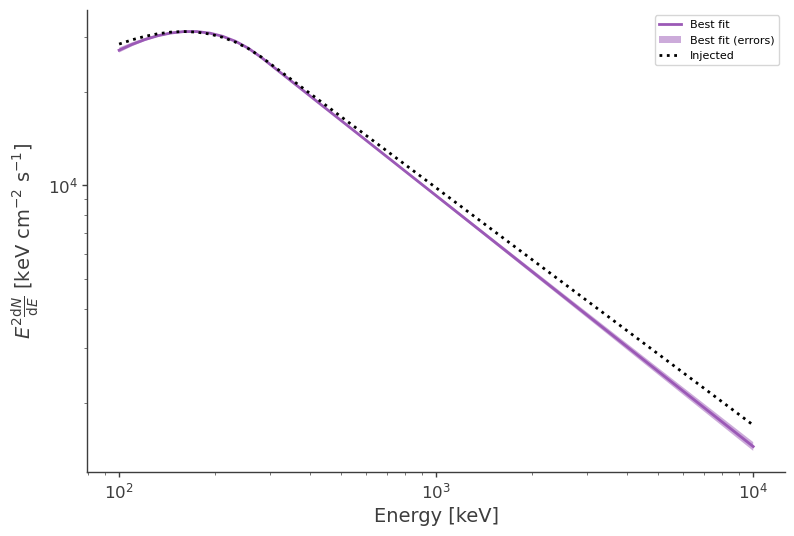

In [22]:
fig, ax = plt.subplots(figsize = (9, 6))

ax.plot(energy, energy**2 * flux_median, label = "Best fit")
ax.fill_between(energy, energy**2 * flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy**2 * flux_inj, color = 'black', ls = ":", label = "Injected")

ax.semilogx()
ax.semilogy()

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$E^2 \frac{\mathrm{d}N}{\mathrm{d}E}$ [keV cm$^{-2}$ s$^{-1}$]")

ax.legend();
